# Contract Risk Scoring — CUAD Fine-Tuning
**Fresnel Fabian | MPS Applied Machine Intelligence | Northeastern Roux Institute**

| | Contracts | QA Pairs | Positive | Negative |
|---|---|---|---|---|
| Train (`train_separate_questions.json`) | 408 | 22,450 | 11,180 | 11,270 |
| Test (`test.json`) | 102 | 4,182 | 1,244 | 2,938 |

**41 clause types** including: `Uncapped Liability`, `Cap On Liability`, `Ip Ownership Assignment`, `Change Of Control`, `Liquidated Damages`, `Non-Compete`, `Source Code Escrow`...


## Cell 1 — GPU + Install

In [ ]:
import torch
assert torch.cuda.is_available(), 'No GPU — Runtime → Change runtime type → T4 GPU'
print(f'GPU:  {torch.cuda.get_device_name(0)}')
print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

!pip install -q 'transformers==4.41.2' datasets accelerate

import transformers
print(f'transformers: {transformers.__version__}')

GPU:  NVIDIA A100-SXM4-40GB
VRAM: 42.4 GB
transformers: 4.41.2


## Cell 2 — Mount Drive + Upload data.zip

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
BASE = '/content/drive/MyDrive/contract_risk_cuad'
for d in [BASE, f'{BASE}/data', f'{BASE}/model', f'{BASE}/results']:
    os.makedirs(d, exist_ok=True)
print('Project folder:', BASE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project folder: /content/drive/MyDrive/contract_risk_cuad


In [ ]:
import os, zipfile, json

TRAIN_FILE = f'{BASE}/data/train_separate_questions.json'
TEST_FILE  = f'{BASE}/data/test.json'

if not os.path.exists(TRAIN_FILE):
    from google.colab import files
    print('Select data.zip...')
    uploaded = files.upload()
    import shutil
    zip_src = list(uploaded.keys())[0]
    shutil.copy(zip_src, f'{BASE}/data.zip')
    with zipfile.ZipFile(f'{BASE}/data.zip') as z:
        z.extractall(f'{BASE}/data')
    print('Extracted.')
else:
    print('Data already on Drive.')

# Print stats
for path, label in [(TRAIN_FILE, 'Train'), (TEST_FILE, 'Test')]:
    with open(path) as f: d = json.load(f)
    qas = [q for c in d['data'] for p in c['paragraphs'] for q in p['qas']]
    pos = sum(1 for q in qas if q['answers'])
    print(f'{label}: {len(d["data"])} contracts  {len(qas)} QA pairs  '
          f'({pos} positive / {len(qas)-pos} negative)')

Data already on Drive.
Train: 408 contracts  22450 QA pairs  (11180 positive / 11270 negative)
Test: 102 contracts  4182 QA pairs  (1244 positive / 2938 negative)


## Cell 3 — Configuration

**Model options:**
- `'roberta-base'` — strong general baseline (recommended to start)
- `'nlpaueb/legal-bert-base-uncased'` — pre-trained on legal text
- `'deepset/roberta-base-squad2'` — already fine-tuned on SQuAD2, fastest convergence

**T4 (16 GB):** keep defaults. **A100:** set `BATCH=16, ACCUM=2`.

In [ ]:
MODEL_NAME = "bert-base-uncased"  # or LegalBERT variant
EPOCHS     = 4
BATCH      = 8              # per-GPU batch  (T4: 8, A100: 16)
ACCUM      = 4              # accumulation   → effective batch = 32
LR         = 3e-5
MAX_LEN    = 384            # token window   (384 fits T4; 512 if more VRAM)
STRIDE     = 128            # window overlap
SEED       = 42

MODEL_DIR  = f'{BASE}/model/{MODEL_NAME.split("/")[-1]}'
os.makedirs(MODEL_DIR, exist_ok=True)

print(f'Model:           {MODEL_NAME}')
print(f'Epochs:          {EPOCHS}')
print(f'Effective batch: {BATCH * ACCUM}')
print(f'Token window:    {MAX_LEN}  stride={STRIDE}')
print(f'Output:          {MODEL_DIR}')

Model:           bert-base-uncased
Epochs:          4
Effective batch: 32
Token window:    384  stride=128
Output:          /content/drive/MyDrive/contract_risk_cuad/model/bert-base-uncased


## Cell 4 — Load + Tokenize

Your data is SQuAD v2 format. For each of the 41 clause types, the model is asked a question like:
> *"Highlight the parts (if any) related to 'Uncapped Liability'."*

It learns to find the exact text span in the contract that answers it.
If the clause is absent, `is_impossible=True` and the answer is empty.


In [ ]:
import json
from datasets import Dataset
from transformers import AutoTokenizer

def flatten_squad(path):
    """Flatten SQuAD v2 JSON → flat list of QA examples."""
    with open(path) as f:
        raw = json.load(f)
    out = []
    for contract in raw['data']:
        for para in contract['paragraphs']:
            ctx = para['context']
            for qa in para['qas']:
                out.append({
                    'id':            qa['id'],
                    'context':       ctx,
                    'question':      qa['question'],
                    'answers': {
                        'text':         [a['text']         for a in qa['answers']],
                        'answer_start': [a['answer_start'] for a in qa['answers']],
                    },
                    'is_impossible': qa.get('is_impossible', len(qa['answers']) == 0),
                })
    return out

print('Flattening data...')
train_examples = flatten_squad(TRAIN_FILE)
test_examples  = flatten_squad(TEST_FILE)
train_ds = Dataset.from_list(train_examples)
test_ds  = Dataset.from_list(test_examples)
print(f'Train: {len(train_ds)} examples')
print(f'Test:  {len(test_ds)} examples')

# Show a sample
ex = train_ds[0]
print(f'\nSample:')
print(f'  id:        {ex["id"][:70]}')
print(f'  question:  {ex["question"][:80]}')
print(f'  context:   {ex["context"][:80]}...')
print(f'  answers:   {ex["answers"]}')
print(f'  impossible:{ex["is_impossible"]}')

Flattening data...
Train: 22450 examples
Test:  4182 examples

Sample:
  id:        LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT__Document Name_0
  question:  Highlight the parts (if any) of this contract related to "Document Name" that sh
  context:   EXHIBIT 10.6

                              DISTRIBUTOR AGREEMENT

         THIS...
  answers:   {'answer_start': [44], 'text': ['DISTRIBUTOR AGREEMENT']}
  impossible:False


In [ ]:
from transformers import BertTokenizerFast
from datasets import DatasetDict

print(f'Loading tokenizer: {MODEL_NAME}')
tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)

# =======================
# Tokenization for train
# =======================
def tokenize_train(examples):
    """Tokenize + safely compute start/end token positions with clamping."""
    tok = tokenizer(
        examples['question'], examples['context'],
        max_length=MAX_LEN,
        truncation='only_second',
        stride=STRIDE,
        return_overflowing_tokens=True,
        return_offsets_mapping=True,
        padding='max_length'
    )

    sample_map = tok.pop('overflow_to_sample_mapping')
    offsets    = tok.pop('offset_mapping')
    cls_id     = tokenizer.cls_token_id
    starts, ends = [], []

    for i, off in enumerate(offsets):
        idx     = sample_map[i]
        answers = examples['answers'][idx]
        input_ids_len = len(tok['input_ids'][i])
        cls_pos = min(tok['input_ids'][i].index(cls_id), input_ids_len - 1)

        # No answer → point to CLS
        if not answers['answer_start']:
            starts.append(cls_pos)
            ends.append(cls_pos)
            continue

        cs = answers['answer_start'][0]
        ce = cs + len(answers['text'][0])

        seq_ids = tok.sequence_ids(i)
        ctx_s   = next(j for j, s in enumerate(seq_ids) if s == 1)
        ctx_e   = len(seq_ids) - next(j for j, s in enumerate(reversed(seq_ids)) if s == 1) - 1

        # Answer not fully in window → CLS
        if off[ctx_s][0] > cs or off[ctx_e][1] < ce:
            starts.append(cls_pos)
            ends.append(cls_pos)
            continue

        ts = te = ctx_s
        for j in range(ctx_s, ctx_e + 1):
            if off[j][0] <= cs:
                ts = j
        for j in range(ctx_e, ctx_s - 1, -1):
            if off[j][1] >= ce:
                te = j
                break

        # Clamp to input length to avoid device assert
        ts = min(ts, input_ids_len - 1)
        te = min(te, input_ids_len - 1)

        starts.append(ts)
        ends.append(te)

    tok['start_positions'] = starts
    tok['end_positions']   = ends
    return tok


# =======================
# Tokenization for eval / validation
# =======================
def tokenize_eval(examples):
    tok = tokenizer(
        examples['question'], examples['context'],
        max_length=MAX_LEN,
        truncation='only_second',
        stride=STRIDE,
        return_overflowing_tokens=True,
        return_offsets_mapping=True,
        padding='max_length'
    )

    sample_map = tok['overflow_to_sample_mapping']
    tok['example_id'] = [examples['id'][sample_map[i]] for i in range(len(sample_map))]
    tok['offset_mapping'] = [
        [o if tok.sequence_ids(i)[j] == 1 else None
         for j, o in enumerate(off)]
        for i, off in enumerate(tok['offset_mapping'])
    ]
    return tok


# =======================
# Create train + validation split
# =======================
split = train_ds.train_test_split(test_size=0.1, seed=42)
train_ds = split['train']
val_ds   = split['test']

# Tokenize datasets
print('Tokenizing train set...')
train_tok = train_ds.map(tokenize_train, batched=True,
                          remove_columns=train_ds.column_names, num_proc=2)
print(f'  {len(train_tok)} features')

print('Tokenizing validation set...')
val_tok = val_ds.map(tokenize_eval, batched=True,
                      remove_columns=val_ds.column_names, num_proc=2)
print(f'  {len(val_tok)} features')

print('Tokenizing test set...')
test_tok = test_ds.map(tokenize_eval, batched=True,
                        remove_columns=test_ds.column_names, num_proc=2)
print(f'  {len(test_tok)} features')

Loading tokenizer: bert-base-uncased
Tokenizing train set...


Map (num_proc=2):   0%|          | 0/18184 [00:00<?, ? examples/s]

  1232320 features
Tokenizing validation set...


Map (num_proc=2):   0%|          | 0/2021 [00:00<?, ? examples/s]

  135605 features
Tokenizing test set...


Map (num_proc=2):   0%|          | 0/4182 [00:00<?, ? examples/s]

  203573 features


In [ ]:
train_tok.save_to_disk("train_tok")
test_tok.save_to_disk("test_tok")
val_tok.save_to_disk("val_tok")

Saving the dataset (0/6 shards):   0%|          | 0/1232320 [00:00<?, ? examples/s]

Saving the dataset (0/4 shards):   0%|          | 0/203573 [00:00<?, ? examples/s]

Saving the dataset (0/3 shards):   0%|          | 0/135605 [00:00<?, ? examples/s]

In [ ]:
from datasets import load_from_disk

train_tok = load_from_disk("train_tok")
test_tok  = load_from_disk("test_tok")

split = train_tok.train_test_split(test_size=0.1, seed=42)
train_tok = split['train']
val_tok   = split['test']

print(f"Train size: {len(train_tok)}")
print(f"Validation size: {len(val_tok)}")
print(f"Test size: {len(test_tok)}")

Train size: 1109088
Validation size: 123232
Test size: 203573


## Cell 5 — Model + Train

In [ ]:
from transformers import BertForQuestionAnswering, BertTokenizerFast
from torch.utils.data import DataLoader
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
import torch, time, random, numpy as np

# =======================
# Setup
# =======================
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# TF32 (Ampere+ GPUs)
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

# =======================
# Model + Tokenizer
# =======================
model = BertForQuestionAnswering.from_pretrained(MODEL_NAME).to(DEVICE)
tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)

# Optional speed boost (PyTorch 2.x)
if hasattr(torch, "compile"):
    model = torch.compile(model)

n = sum(p.numel() for p in model.parameters())
print(f'Parameters: {n:,} ({n/1e6:.0f}M)')

# =======================
# Data
# =======================
train_tok.set_format('torch', columns=[
    'input_ids','attention_mask','start_positions','end_positions'
])

# If val_ds has labels (answers), tokenize like train:
val_tok = val_ds.map(tokenize_train, batched=True, remove_columns=val_ds.column_names, num_proc=2)
val_tok.set_format('torch', columns=['input_ids','attention_mask','start_positions','end_positions'])

train_loader = DataLoader(
    train_tok, batch_size=BATCH, shuffle=True,
    num_workers=2, pin_memory=True
)

val_loader = DataLoader(
    val_tok, batch_size=BATCH, shuffle=False,
    num_workers=2, pin_memory=True
)

# =======================
# Optimizer & Scheduler
# =======================
total_steps  = (len(train_loader) // ACCUM) * EPOCHS
warmup_steps = int(0.06 * total_steps)

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)

scheduler = get_linear_schedule_with_warmup(
    optimizer, warmup_steps, total_steps
)

scaler = torch.cuda.amp.GradScaler()

print(f'Steps/epoch: {len(train_loader)//ACCUM}   Total: {total_steps}')
print(f'Effective batch: {BATCH * ACCUM}')
print('Training...')
print('='*50)

# =======================
# Training Loop
# =======================
t0 = time.time()
best_val_loss = float('inf')

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0
    running_loss = 0.0
    optimizer.zero_grad()

    for step, batch in enumerate(train_loader):
        ids   = batch['input_ids'].to(DEVICE, non_blocking=True)
        mask  = batch['attention_mask'].to(DEVICE, non_blocking=True)
        start = batch['start_positions'].to(DEVICE, non_blocking=True)
        end   = batch['end_positions'].to(DEVICE, non_blocking=True)

        with torch.cuda.amp.autocast():
            out = model(
                input_ids=ids,
                attention_mask=mask,
                start_positions=start,
                end_positions=end
            )
            loss = out.loss / ACCUM

        scaler.scale(loss).backward()

        total_loss += loss.item() * ACCUM
        running_loss += loss.item()

        # Gradient accumulation step
        if (step + 1) % ACCUM == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()

        # Logging
        if (step + 1) % 100 == 0:
            print(f'E{epoch+1} step {step+1}/{len(train_loader)} '
                  f'loss={running_loss/100:.4f}')
            running_loss = 0.0

    # 🔥 Fix: handle leftover gradients
    if len(train_loader) % ACCUM != 0:
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        optimizer.zero_grad()

    avg_train_loss = total_loss / len(train_loader)

    # =======================
    # Validation
    # =======================
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for batch in val_loader:
            ids   = batch['input_ids'].to(DEVICE, non_blocking=True)
            mask  = batch['attention_mask'].to(DEVICE, non_blocking=True)
            start = batch['start_positions'].to(DEVICE, non_blocking=True)
            end   = batch['end_positions'].to(DEVICE, non_blocking=True)

            with torch.cuda.amp.autocast():
                out = model(
                    input_ids=ids,
                    attention_mask=mask,
                    start_positions=start,
                    end_positions=end
                )

            val_loss += out.loss.item()

    val_loss /= len(val_loader)

    print(f'\nEpoch {epoch+1}/{EPOCHS}')
    print(f'Train Loss: {avg_train_loss:.4f}')
    print(f'Val   Loss: {val_loss:.4f}')
    print(f'Time elapsed: {(time.time()-t0)/60:.1f} min')
    print('-'*50)

    # =======================
    # Save Best Model
    # =======================
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        model.save_pretrained(MODEL_DIR)
        tokenizer.save_pretrained(MODEL_DIR)
        print('✅ Saved best model')

# =======================
# Done
# =======================
print(f'\nTraining complete!')
print(f'Best validation loss: {best_val_loss:.4f}')
print(f'Total time: {(time.time()-t0)/60:.1f} min')

Some weights of BertForQuestionAnswering were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['qa_outputs.bias', 'qa_outputs.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Parameters: 108,893,186 (109M)


Map (num_proc=2):   0%|          | 0/2245 [00:00<?, ? examples/s]

Steps/epoch: 42747   Total: 170988
Effective batch: 32
Training...


/tmp/ipykernel_21970/591571514.py:67: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_21970/591571514.py:92: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_21970/591571514.py:92: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


...


Epoch 1/4
Train Loss: 0.0798
Val   Loss: 0.0336
Time elapsed: 106.0 min
--------------------------------------------------
✅ Saved best model


/tmp/ipykernel_21970/591571514.py:92: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


E2 step 100/170991 loss=0.0094
E2 step 200/170991 loss=0.0063
E2 step 300/170991 loss=0.0102
E2 step 400/170991 loss=0.0078
E2 step 500/170991 loss=0.0151
E2 step 600/170991 loss=0.0078
E2 step 700/170991 loss=0.0109
E2 step 800/170991 loss=0.0042
E2 step 900/170991 loss=0.0061
E2 step 1000/170991 loss=0.0101
E2 step 1100/170991 loss=0.0042
E2 step 1200/170991 loss=0.0094
E2 step 1300/170991 loss=0.0089
E2 step 1400/170991 loss=0.0097
E2 step 1500/170991 loss=0.0104
E2 step 1600/170991 loss=0.0041
E2 step 1700/170991 loss=0.0112
E2 step 1800/170991 loss=0.0186
E2 step 1900/170991 loss=0.0040
E2 step 2000/170991 loss=0.0164
E2 step 2100/170991 loss=0.0064
E2 step 2200/170991 loss=0.0049
E2 step 2300/170991 loss=0.0123
E2 step 2400/170991 loss=0.0090
E2 step 2500/170991 loss=0.0063
E2 step 2600/170991 loss=0.0068
E2 step 2700/170991 loss=0.0113
E2 step 2800/170991 loss=0.0057
E2 step 2900/170991 loss=0.0091
E2 step 3000/170991 loss=0.0085
E2 step 3100/170991 loss=0.0138
E2 step 3200/1709

/tmp/ipykernel_21970/591571514.py:147: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():



Epoch 2/4
Train Loss: 0.0333
Val   Loss: 0.0293
Time elapsed: 207.8 min
--------------------------------------------------
✅ Saved best model
E3 step 100/170991 loss=0.0109
E3 step 200/170991 loss=0.0020
E3 step 300/170991 loss=0.0051
E3 step 400/170991 loss=0.0081
E3 step 500/170991 loss=0.0145
E3 step 600/170991 loss=0.0104
E3 step 700/170991 loss=0.0076
E3 step 800/170991 loss=0.0052
E3 step 900/170991 loss=0.0082
E3 step 1000/170991 loss=0.0068
E3 step 1100/170991 loss=0.0047
E3 step 1200/170991 loss=0.0081
E3 step 1300/170991 loss=0.0094
E3 step 1400/170991 loss=0.0036
E3 step 1500/170991 loss=0.0107
E3 step 1600/170991 loss=0.0050
E3 step 1700/170991 loss=0.0058
E3 step 1800/170991 loss=0.0069
E3 step 1900/170991 loss=0.0079
E3 step 2000/170991 loss=0.0067
E3 step 2100/170991 loss=0.0020
E3 step 2200/170991 loss=0.0027
E3 step 2300/170991 loss=0.0054
E3 step 2400/170991 loss=0.0034
E3 step 2500/170991 loss=0.0085
E3 step 2600/170991 loss=0.0067
E3 step 2700/170991 loss=0.0069
E3

## Cell 6 — Extract Predictions

Converts start/end logits into text spans. Uses the same Jaccard ≥ 0.5 match criterion as the CUAD paper.

In [ ]:
import collections, numpy as np, json
from tqdm.auto import tqdm
from torch.utils.data import DataLoader
from transformers import BertForQuestionAnswering
import torch

# =======================
# Setup
# =======================
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load the fine-tuned BERT QA model
eval_model = BertForQuestionAnswering.from_pretrained(MODEL_DIR).to(DEVICE)
eval_model.eval()

# Prepare test dataset (drop unnecessary columns)
eval_input = test_tok.remove_columns(['example_id', 'offset_mapping'])
eval_input.set_format('torch')
loader = DataLoader(eval_input, batch_size=32, shuffle=False)

# =======================
# Run inference
# =======================
print('Running inference...')
start_logits_list, end_logits_list = [], []

for batch in tqdm(loader):
    with torch.no_grad():
        out = eval_model(
            input_ids=batch['input_ids'].to(DEVICE),
            attention_mask=batch['attention_mask'].to(DEVICE)
        )
    start_logits_list.append(out.start_logits.cpu().numpy())
    end_logits_list.append(out.end_logits.cpu().numpy())

start_logits = np.concatenate(start_logits_list)
end_logits   = np.concatenate(end_logits_list)
print(f'Logits shapes: {start_logits.shape}, {end_logits.shape}')

# =======================
# Post-process: logits → text spans
# =======================
feat_for_id = collections.defaultdict(list)
for i, ex_id in enumerate(test_tok['example_id']):
    feat_for_id[ex_id].append(i)

predictions, nbest_preds = {}, {}
N_BEST, MAX_ANS = 20, 250

for ex in tqdm(test_ds, desc='Post-processing'):
    ex_id   = ex['id']
    context = ex['context']
    valid   = []
    null_score = float('inf')

    for fi in feat_for_id[ex_id]:
        sl, el  = start_logits[fi], end_logits[fi]
        offsets = test_tok['offset_mapping'][fi]
        null_score = min(null_score, sl[0] + el[0])

        # Top N_BEST logits
        top_s = np.argsort(sl)[-N_BEST:]
        top_e = np.argsort(el)[-N_BEST:]

        for si in top_s:
            for ei in top_e:
                # Skip invalid spans
                if (si >= len(offsets) or ei >= len(offsets) or
                        offsets[si] is None or offsets[ei] is None or
                        ei < si or ei - si + 1 > MAX_ANS):
                    continue
                text_span = context[offsets[si][0]: offsets[ei][1]]
                valid.append({'score': float(sl[si]+el[ei]), 'text': text_span})

    # Sort by score descending
    valid.sort(key=lambda x: -x['score'])
    valid = valid[:N_BEST]

    if valid:
        scores = np.array([v['score'] for v in valid] + [null_score])
        exp    = np.exp(scores - scores.max())
        probs  = exp / exp.sum()
        # Choose null if probability higher
        if probs[-1] > probs[0]:
            predictions[ex_id] = ''
            nbest_preds[ex_id] = [{'text':'','probability':float(probs[-1])}]
        else:
            predictions[ex_id] = valid[0]['text']
            nbest_preds[ex_id] = [{'text':v['text'],'probability':float(p)}
                                   for v,p in zip(valid, probs[:-1])]
    else:
        predictions[ex_id] = ''
        nbest_preds[ex_id] = [{'text':'','probability':1.0}]

# =======================
# Save predictions
# =======================
import os
os.makedirs(f'{BASE}/results', exist_ok=True)

with open(f'{BASE}/results/nbest_predictions.json', 'w') as f:
    json.dump(nbest_preds, f)
with open(f'{BASE}/results/predictions.json', 'w') as f:
    json.dump(predictions, f)

non_empty = sum(1 for v in predictions.values() if v)
print(f'\nPredictions: {len(predictions)} total, {non_empty} non-empty')

Running inference...


  0%|          | 0/6362 [00:00<?, ?it/s]

Logits shapes: (203573, 384), (203573, 384)


Post-processing:   0%|          | 0/4182 [00:00<?, ?it/s]


Predictions: 4182 total, 569 non-empty


## Cell 7 — Metrics (AUPR, Precision@Recall)

In [ ]:
import numpy as np
from sklearn import metrics as sk_metrics

IOU_THRESH = 0.5

gt = {ex['id']: ex['answers']['text'] for ex in test_ds}

def jaccard(a, b):
    for t in ['.', ',', ';', ':']:
        a = a.replace(t,''); b = b.replace(t,'')
    a,b = a.lower().replace('/',' '), b.lower().replace('/',' ')
    wa, wb = set(a.split()), set(b.split())
    return len(wa&wb)/len(wa|wb) if (wa or wb) else 1.0

def is_match(gt_text, pred_text, parties=False):
    j = jaccard(gt_text, pred_text)
    return j >= IOU_THRESH or (parties and gt_text in pred_text)

def pr_at_conf(nbest, gt_dict, conf, category=None):
    tp=fp=fn=0
    for ex_id, answers in gt_dict.items():
        if category and category not in ex_id: continue
        parties = 'Parties' in ex_id
        preds   = [p['text'] for p in nbest.get(ex_id,[])
                   if p['probability'] > conf and p['text']]
        if not answers:
            fp += len(preds)
        else:
            for ans in answers:
                if any(is_match(ans,p,parties) for p in preds): tp+=1
                else: fn+=1
            for p in preds:
                if not any(is_match(ans,p,parties) for ans in answers): fp+=1
    prec = tp/(tp+fp) if (tp+fp)>0 else np.nan
    rec  = tp/(tp+fn) if (tp+fn)>0 else np.nan
    return prec, rec

def pr_curve(nbest, gt_dict, category=None):
    precs,recs = [1.0],[0.0]
    for c in list(np.arange(0.99,0,-0.01)) + [0.001, 0.0]:
        p,r = pr_at_conf(nbest, gt_dict, c, category)
        precs.append(p); recs.append(r)
    return np.array(precs), np.array(recs)

def compute_aupr(precs, recs):
    p = precs.copy()
    for i in range(len(p)-2,-1,-1): p[i]=max(p[i],p[i+1])
    p = np.nan_to_num(p)
    v = sk_metrics.auc(recs, p)
    return 0.0 if np.isnan(v) else float(v)

def prec_at_recall(precs, recs, thresh=0.9):
    p = precs.copy()
    for i in range(len(p)-2,-1,-1): p[i]=max(p[i],p[i+1])
    for pi, ri in zip(p, recs):
        if ri >= thresh: return float(pi)
    return 0.0

print('Computing overall metrics...')
precs, recs   = pr_curve(nbest_preds, gt)
overall_aupr  = compute_aupr(precs, recs)
p80           = prec_at_recall(precs, recs, 0.80)
p90           = prec_at_recall(precs, recs, 0.90)

print()
print('='*50)
print('RESULTS')
print('='*50)
print(f'  AUPR:                  {overall_aupr:.4f}')
print(f'  Precision @ 80% recall: {p80:.4f}')
print(f'  Precision @ 90% recall: {p90:.4f}')

Computing overall metrics...

RESULTS
  AUPR:                  0.0741
  Precision @ 80% recall: 0.0000
  Precision @ 90% recall: 0.0000


## Cell 8 — Per-Clause Results

In [ ]:
# The 41 clause types in your data (from the QA IDs)
CLAUSE_TYPES = [
    'Affiliate License-Licensee','Affiliate License-Licensor','Agreement Date',
    'Anti-Assignment','Audit Rights','Cap On Liability','Change Of Control',
    'Competitive Restriction Exception','Covenant Not To Sue','Document Name',
    'Effective Date','Exclusivity','Expiration Date','Governing Law','Insurance',
    'Ip Ownership Assignment','Irrevocable Or Perpetual License','Joint Ip Ownership',
    'License Grant','Liquidated Damages','Minimum Commitment','Most Favored Nation',
    'No-Solicit Of Customers','No-Solicit Of Employees','Non-Compete',
    'Non-Disparagement','Non-Transferable License','Notice Period To Terminate Renewal',
    'Parties','Post-Termination Services','Price Restrictions','Renewal Term',
    'Revenue/Profit Sharing','Rofr/Rofo/Rofn','Source Code Escrow',
    'Termination For Convenience','Third Party Beneficiary','Uncapped Liability',
    'Unlimited/All-You-Can-Eat-License','Volume Restriction','Warranty Duration',
]

cat_results = []
for ct in CLAUSE_TYPES:
    pc, rc   = pr_curve(nbest_preds, gt, category=ct)
    n_pos    = sum(1 for k,v in gt.items() if ct in k and v)
    cat_results.append({
        'clause': ct, 'aupr': compute_aupr(pc, rc),
        'p80': prec_at_recall(pc, rc, 0.80),
        'p90': prec_at_recall(pc, rc, 0.90),
        'n_pos': n_pos,
    })

cat_results.sort(key=lambda x: -x['aupr'])

print(f'{"Clause Type":<40} {"AUPR":>6}  {"P@80":>6}  {"P@90":>6}  {"N+":>4}')
print('-'*68)
for r in cat_results:
    bar  = '█' * int(r['aupr'] * 20)
    flag = '  ⚠' if r['aupr'] < 0.30 else ''
    print(f"{r['clause']:<40} {r['aupr']:>6.3f}  {r['p80']:>6.3f}  "
          f"{r['p90']:>6.3f}  {r['n_pos']:>4}  {bar}{flag}")

auprs = [r['aupr'] for r in cat_results]
print(f'\nMean AUPR:   {np.mean(auprs):.4f}')
print(f'Median AUPR: {np.median(auprs):.4f}')
print(f'Best:  {cat_results[0]["clause"]}  ({cat_results[0]["aupr"]:.3f})')
print(f'Worst: {cat_results[-1]["clause"]}  ({cat_results[-1]["aupr"]:.3f})')

with open(f'{BASE}/results/per_clause.json','w') as f:
    json.dump(cat_results, f, indent=2)
print(f'\nSaved: {BASE}/results/per_clause.json')

Clause Type                                AUPR    P@80    P@90    N+
--------------------------------------------------------------------
Parties                                   0.652   0.000   0.000   102  █████████████
No-Solicit Of Employees                   0.492   0.000   0.000    10  █████████
Renewal Term                              0.252   0.000   0.000    26  █████  ⚠
Notice Period To Terminate Renewal        0.248   0.000   0.000    16  ████  ⚠
Governing Law                             0.174   0.000   0.000    83  ███  ⚠
Expiration Date                           0.160   0.000   0.000    78  ███  ⚠
No-Solicit Of Customers                   0.094   0.000   0.000     7  █  ⚠
Anti-Assignment                           0.090   0.000   0.000    72  █  ⚠
Termination For Convenience               0.058   0.000   0.000    29  █  ⚠
Exclusivity                               0.052   0.000   0.000    33  █  ⚠
Cap On Liability                          0.033   0.000   0.000    44    ⚠
U

## Cell 9 — Charts

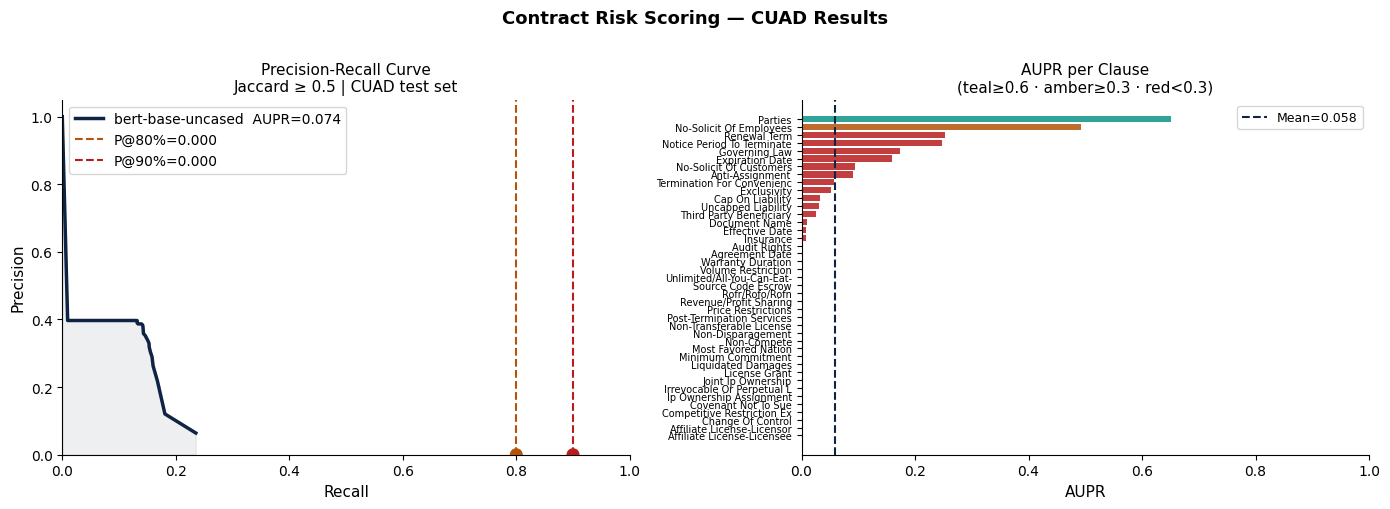

Saved: /content/drive/MyDrive/contract_risk_cuad/results/results.png


In [ ]:
import matplotlib.pyplot as plt
NAVY,TEAL,AMBER,RED = '#0F2444','#0D9488','#B45309','#B91C1C'

mono = precs.copy()
for i in range(len(mono)-2,-1,-1): mono[i]=max(mono[i],mono[i+1])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(recs, mono, color=NAVY, lw=2.5,
        label=f'{MODEL_NAME}  AUPR={overall_aupr:.3f}')
ax.fill_between(recs, mono, alpha=0.07, color=NAVY)
ax.axvline(0.80, color=AMBER, ls='--', lw=1.5, label=f'P@80%={p80:.3f}')
ax.axvline(0.90, color=RED,   ls='--', lw=1.5, label=f'P@90%={p90:.3f}')
ax.scatter([0.80,0.90], [p80,p90], s=70, zorder=5, color=[AMBER,RED])
ax.set_xlim(0,1); ax.set_ylim(0,1.05)
ax.set_xlabel('Recall',fontsize=11); ax.set_ylabel('Precision',fontsize=11)
ax.set_title('Precision-Recall Curve\nJaccard ≥ 0.5 | CUAD test set',fontsize=11)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

ax = axes[1]
cr = sorted(cat_results, key=lambda x: x['aupr'])
names  = [r['clause'][:26] for r in cr]
avals  = [r['aupr'] for r in cr]
bcolors= [TEAL if a>=0.6 else AMBER if a>=0.3 else RED for a in avals]
ax.barh(range(len(names)), avals, color=bcolors, alpha=0.85)
ax.axvline(np.mean(avals), color=NAVY, ls='--', lw=1.5,
           label=f'Mean={np.mean(avals):.3f}')
ax.set_yticks(range(len(names))); ax.set_yticklabels(names, fontsize=7)
ax.set_xlabel('AUPR',fontsize=11); ax.set_xlim(0,1)
ax.set_title('AUPR per Clause\n(teal≥0.6 · amber≥0.3 · red<0.3)',fontsize=11)
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.suptitle('Contract Risk Scoring — CUAD Results',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
fig_path = f'{BASE}/results/results.png'
plt.savefig(fig_path, dpi=130, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path}')

## Cell 10 — Score a Contract

Paste any contract text. The model runs all 41 clause questions and returns a risk score 0–100.

In [ ]:
import torch.nn.functional as F
import torch
from transformers import BertForQuestionAnswering, BertTokenizerFast

# =======================
# Device
# =======================
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# =======================
# Load model & tokenizer
# =======================
# Use BertForQuestionAnswering since your model was fine-tuned with BERT
inf_model = BertForQuestionAnswering.from_pretrained(MODEL_DIR).to(DEVICE)
inf_model.eval()

# Use the fast tokenizer from the same directory
inf_tok = BertTokenizerFast.from_pretrained(MODEL_DIR)

print(f'Model loaded: {MODEL_DIR}')
print(f'Device: {DEVICE}')

# Question text for each clause (matches the format in your data)
QUESTIONS = {ct: f'Highlight the parts (if any) of this contract related to "{ct}".'
             for ct in CLAUSE_TYPES}

RISK_WEIGHT = {
    'Uncapped Liability':10,'Cap On Liability':9,'Ip Ownership Assignment':9,
    'Joint Ip Ownership':8,'Change Of Control':8,'Liquidated Damages':7,
    'Anti-Assignment':7,'Source Code Escrow':7,'Non-Compete':6,
    'Audit Rights':6,'Covenant Not To Sue':6,'Most Favored Nation':6,
    'Irrevocable Or Perpetual License':6,'Unlimited/All-You-Can-Eat-License':6,
    'Termination For Convenience':5,'Exclusivity':5,'Rofr/Rofo/Rofn':5,
    'Revenue/Profit Sharing':5,'Competitive Restriction Exception':5,
}

@torch.no_grad()
def score_contract(text, conf=0.1):
    detected = []
    for clause, question in QUESTIONS.items():
        enc = inf_tok(
            question, text, max_length=MAX_LEN, truncation='only_second',
            stride=STRIDE, return_overflowing_tokens=True,
            return_offsets_mapping=True, padding='max_length', return_tensors='pt',
        )
        offs = enc.pop('offset_mapping')
        enc.pop('overflow_to_sample_mapping', None)
        enc  = {k: v.to(DEVICE) for k,v in enc.items()}
        out  = inf_model(**enc)

        best_conf, best_text = 0.0, ''
        for i in range(len(out.start_logits)):
            si = out.start_logits[i].argmax().item()
            ei = out.end_logits[i].argmax().item()
            if si > ei: continue
            c = (F.softmax(out.start_logits[i],dim=-1)[si] *
                 F.softmax(out.end_logits[i],  dim=-1)[ei]).item()
            if c > best_conf:
                o = offs[i]
                if o[si] is None or o[ei] is None: continue
                cs,ce = o[si][0].item(), o[ei][1].item()
                if cs==0 and ce==0: continue
                best_conf, best_text = c, text[cs:ce].strip()

        if best_conf >= conf and best_text:
            detected.append({'clause':clause,'text':best_text,
                              'conf':round(best_conf,4),
                              'weight':RISK_WEIGHT.get(clause,3)})

    detected.sort(key=lambda x: x['weight']*x['conf'], reverse=True)

    if detected:
        w = np.array([d['weight'] for d in detected],dtype=float)
        c = np.array([d['conf']   for d in detected],dtype=float)
        raw   = float(np.dot(w/w.sum(), c))
        boost = sum(d['conf']*d['weight'] for d in detected if d['weight']>=7)
        score = min(100, int(raw*80 + boost*3))
    else:
        score = 0

    triage = ('AUTO-CLEAR'      if score<30 else
              'FLAG FOR REVIEW'  if score<65 else
              'URGENT REVIEW')
    return {'score':score,'triage':triage,'clauses':detected}


# ── Test it ────────────────────────────────────────────────────────────────────
CONTRACTS = {
    'High-Risk SaaS': """SOFTWARE AS A SERVICE AGREEMENT
This Agreement is entered into between TechVendor Inc. and Customer Corp.
All intellectual property shall be assigned to Vendor. There shall be no cap
on liability — liability shall not be limited or capped under any circumstances.
The agreement auto-renews annually unless terminated with 90 days prior notice.
Customer agrees to a non-compete for 24 months post-termination.
Liquidated damages of $500,000 apply for any breach. Change of control requires
Vendor consent. Source code held in escrow.""",

    'Low-Risk NDA': """NON-DISCLOSURE AGREEMENT
This Agreement is entered into as of January 1, 2026 between Party A and Party B.
Both parties agree to keep all information strictly confidential.
Governed by Delaware law. Term is two years. Either party may terminate with 30 days notice.""",
}

for label, contract in CONTRACTS.items():
    r = score_contract(contract)
    print(f'{"="*60}')
    print(f'{label}')
    print(f'Risk Score: {r["score"]}/100   Triage: {r["triage"]}')
    print(f'Detected:   {len(r["clauses"])}/41 clauses')
    for d in r['clauses'][:5]:
        flag = ' ⚠' if d['weight']>=8 else ''
        print(f"  [{d['weight']:>2}/10] {d['clause']:<35} {d['conf']:.3f}  {repr(d['text'][:55])}{flag}")
    print()

Model loaded: /content/drive/MyDrive/contract_risk_cuad/model/bert-base-uncased
Device: cuda
High-Risk SaaS
Risk Score: 0/100   Triage: AUTO-CLEAR
Detected:   0/41 clauses

Low-Risk NDA
Risk Score: 26/100   Triage: AUTO-CLEAR
Detected:   1/41 clauses
  [ 3/10] Governing Law                       0.337  'NON-DISCLOSURE AGREEMENT\nThis Agreement is entered into'



## Cell 11 — Save Results

In [ ]:
import json, os

final = {
    'model': MODEL_NAME, 'epochs': EPOCHS,
    'effective_batch': BATCH*ACCUM, 'learning_rate': LR,
    'aupr': round(overall_aupr, 4),
    'prec_at_80': round(p80, 4),
    'prec_at_90': round(p90, 4),
    'mean_clause_aupr': round(float(np.mean([r['aupr'] for r in cat_results])), 4),
    'per_clause': cat_results,
}
with open(f'{BASE}/results/final_results.json','w') as f:
    json.dump(final, f, indent=2)

print('='*55)
print('FINAL RESULTS')
print('='*55)
print(f'  Model:            {MODEL_NAME}')
print(f'  AUPR:             {final["aupr"]:.4f}')
print(f'  Precision @ 80%:  {final["prec_at_80"]:.4f}')
print(f'  Precision @ 90%:  {final["prec_at_90"]:.4f}')
print(f'  Mean clause AUPR: {final["mean_clause_aupr"]:.4f}')
print()
print('Saved to Drive:')
for fname in sorted(os.listdir(f'{BASE}/results')):
    path = f'{BASE}/results/{fname}'
    print(f'  {fname}  ({os.path.getsize(path)//1024} KB)')

FINAL RESULTS
  Model:            bert-base-uncased
  AUPR:             0.0741
  Precision @ 80%:  0.0000
  Precision @ 90%:  0.0000
  Mean clause AUPR: 0.0582

Saved to Drive:
  final_results.json  (5 KB)
  nbest_predictions.json  (7440 KB)
  per_clause.json  (4 KB)
  predictions.json  (819 KB)
  results.png  (147 KB)
